In [1]:
import os
import librosa
import numpy
import pandas
import glob
import torch


from pathlib import Path

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset


from sentence_transformers import SentenceTransformer

import torch.nn.functional as F

c:\Users\PC\Desktop\project_CSE715_18101194_anika_ahsan\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#hyper parameters

epochs = 100
batch_size = 10
learning_rate = 0.001
latent_dim=64

In [3]:
#dataset directory

current_dir = Path().resolve()
base_dir= Path().resolve().parent
DATASET_PATH_jazz_song = base_dir/ "data" / "medium_task_dataset"/"songs"/"jazz_song"
DATASET_PATH_pop_song = base_dir/ "data" / "medium_task_dataset"/"songs"/"pop_song"


In [4]:
#dataset song

dataset_song=[]

dataset_jazz_song = os.listdir(DATASET_PATH_jazz_song)
dataset_pop_song = os.listdir(DATASET_PATH_pop_song)

dataset_song = dataset_jazz_song + dataset_pop_song

print(dataset_song)


['Amy Winehouse - Love Is A Losing Game.mp3', 'Astrud Gilberto and Stan Getz - The Girl From Ipanema.mp3', 'Billie Holiday - Strange Fruit.mp3', 'Fly Me To The Moon.mp3', 'Grover Washington Jr. - Just the Two of Us.mp3', 'L-O-V-E.mp3', 'Laufey - From The Start.mp3', 'Louis Armstrong - What A Wonderful World.mp3', 'Lovefool - Vintage Jazz Cardigans.mp3', "Norah Jones - Don't Know Why.mp3", 'Parov Stelar - All Night.mp3', 'Royals - (Sad Clown With The Golden Voice).mp3', 'Sade - Smooth Operator.mp3', 'The Girl From Ipanema - Frank Sinatra & Antônio Carlos Jobim.mp3', 'Theme From New York, New York.mp3', 'Adele - Rolling in the Deep.mp3', 'Dua Lipa - Levitating.mp3', 'Dua Lipa - New Rules.mp3', 'Ed Sheeran - Shape of You.mp3', 'Fifth Harmony - Work from Home.mp3', 'Justin Bieber - Baby.mp3', 'Justin Bieber - Let Me Love You.mp3', "Justin Timberlake - CAN'T STOP THE FEELING.mp3", 'Mark Ronson - Uptown Funk.mp3', 'Miley Cyrus - Flowers.mp3', 'Sabrina Carpenter - Espresso.mp3', 'Sabrina Carp

In [5]:
#extract mel spectrogram

melspectrogram=[]

for data in dataset_jazz_song:
    song_path = os.path.join(DATASET_PATH_jazz_song,data)
    y,sr = librosa.load(song_path,duration=30)
    melspectrogram.append(librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128))

for data in dataset_pop_song:
    song_path = os.path.join(DATASET_PATH_pop_song,data)
    y,sr = librosa.load(song_path,duration=30)
    melspectrogram.append(librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128))    

# print('melspectrogram',melspectrogram)

# Convert to log scale 
mel_db=librosa.power_to_db(melspectrogram,ref=numpy.max)

print(mel_db.shape)



#Normalize
mel_db = (mel_db - numpy.mean(mel_db)) / numpy.std(mel_db)
for i in mel_db:
    print(i.shape)
print(mel_db.shape)




(30, 128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(30, 128, 1292)


In [76]:
#train dataset_song

#numpy array to tensor
dataset_tensor=torch.tensor(mel_db, dtype=torch.float32).unsqueeze(1)
print(dataset_tensor.shape)
dataset = TensorDataset(dataset_tensor)
train_dataset_song=DataLoader(dataset = dataset,
                         batch_size = batch_size,
                         shuffle=True)

print(train_dataset_song)
# for batch in train_dataset_song:
#     print(batch)
#     break

torch.Size([30, 1, 128, 1292])


In [ ]:
latent_dim=64

class CNN_VAE(nn.Module):
    def __init__(self,latent_dim=latent_dim):
        super().__init__()
        
        #encoder
        #4 convolutional layer
        self.encode= nn.Sequential(
            
            # nn.Conv2d(in_channels=1,out_channels=32,kernel_size=4,stride=2,padding=1), #64x64
            # nn.ReLU(),
          
            # nn.Conv2d(32, 64, 4, 2, 1),#32x32
            # nn.ReLU(),

            # nn.Conv2d(64, 128, 4, 2, 1),#16x16
            # nn.ReLU(),

            # nn.Conv2d(128, 256, 4, 2, 1),#8x8
            # nn.ReLU(),

           
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.ReLU(),
          
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU(),

  
            nn.AdaptiveAvgPool2d((4, 4))
             
        )  

  
        self.flatten = nn.Flatten()



        self.mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.logvar = nn.Linear(256 * 4 * 4, latent_dim)


        self.fc_decode = nn.Linear(latent_dim, 256 * 4 * 4)

        #decoder
        # 4 deconvolutional layer
        self.decode=nn.Sequential(
            nn.ConvTranspose2d(in_channels = 256,out_channels = 128,kernel_size= 4,stride= 2,padding= 1),
          
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            
            nn.Sigmoid(),
        ) 
    def encoder(self,x):
    
        x = self.encode(x)
        x = x.view(x.size(0), -1)
        x = self.flatten(x)
        mu = self.mu(x)
        logvar = self.logvar(x)
   
        return mu, logvar 
     
     #z=mu + epsilon*standard deviation
    def reparameterization(self,mu,logvar):
        standard_deviation = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(standard_deviation)
        return mu + epsilon * standard_deviation

    # def decoder(self,z):
      
    #         x = self.fc_decode(z)
    #         x = x.view(-1, 256, 4, 4)
    #         x = self.decode(x)
    #         return x

    def decoder(self, z):
        x = self.fc_decode(z)         

        # print("BEFORE RESHAPE:", x.shape) 
        x = x.view(x.size(0), 256, 4, 4)   
        # print("AFTER RESHAPE:", x.shape)   
        x = self.decode(x)                

         #FORCE CORRECT SHAPE
        x = F.interpolate(x, size=(128, 1292), mode="bilinear", align_corners=False)

        return x

    def forward(self,x):
        mu, logvar = self.encoder(x)
        z = self.reparameterization(mu, logvar)
        reconstructed_x = self.decoder(z)
        return reconstructed_x, mu, logvar, z  
     






In [111]:
#vae loss function
def vae_loss(reconstructed_x,x,mu,logvar):
    reconstruction_loss=nn.functional.mse_loss(reconstructed_x,x)
    kl=0.5 * torch.sum(mu.pow(2) + logvar.exp() - 1 - logvar )
    
    return reconstruction_loss + kl


In [112]:
#device
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [147]:
model=CNN_VAE()  #creating object of class cnn_vae
optimizer=optim.Adam(model.parameters(),lr=1e-3)

In [119]:
#model training



model.train()

for epoch in range(epochs):
    total_loss=0

    for (x,) in (train_dataset_song):
        
        x = x.to(device)
      
        optimizer.zero_grad()

        x_reconstructed,mu,logvar,z = model(x)  # x_reconstructed, mu, logvar = model.forward(x)
        loss=vae_loss( x_reconstructed,x,mu,logvar)

        loss.backward()
        optimizer.step()

        total_loss=total_loss + loss.item()

    avg_loss=total_loss/len(train_dataset_song.dataset)   


    print(f"epoch [{epoch+1}/{epochs},loss:{avg_loss:.4f}]")






BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
epoch [1/100,loss:0.0804]
BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
epoch [2/100,loss:0.0807]
BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
epoch [3/100,loss:0.0808]
BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
BEFORE RESHAPE: torc

In [121]:
#extract latent features

model.eval()

latent_features=[]
with torch.no_grad():
     for (x,) in (train_dataset_song):
          x=x.to(device)
          x_reconstructed,mu,logvar,z=model(x)
          latent_features.append(mu.cpu().numpy())
          
print(latent_features)
latent_representation = numpy.vstack(latent_features)    
print(latent_representation)   

BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
BEFORE RESHAPE: torch.Size([10, 4096])
AFTER RESHAPE: torch.Size([10, 256, 4, 4])
[array([[-3.20191553e-04,  2.52847152e-04,  1.15125564e-04,
        -3.19787141e-05,  9.86413434e-05, -1.29395194e-04,
         2.90768076e-04, -1.60991895e-05,  2.28276738e-04,
        -1.08776600e-04,  3.32993921e-04, -1.84413002e-05,
        -1.23096601e-04, -7.70083861e-05,  2.13459643e-05,
        -3.99934797e-04, -3.30408424e-04, -2.46113283e-04,
         1.60680385e-04,  2.45605945e-04,  2.84867914e-04,
        -2.11636598e-05, -2.00726528e-04, -1.13815950e-04,
         1.08800683e-04, -3.25982110e-04,  1.11986454e-04,
        -1.64203637e-04,  3.81338206e-04, -2.42539507e-04,
        -2.46312877e-04, -3.11692793e-06,  1.48268693e-04,
        -6.15516838e-05, -9.13164404e-05,  1.13309929e-04,
         2.27280718e-04,  1.01664235e-04,  1.

In [122]:


# pretrained SentenceTransformer model
# 'all-MiniLM-L6-v2' outputs 384-dimensional embeddings
sentence_transformer_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9179.86it/s]


In [124]:
#dataset directory
current_dir = Path().resolve()
base_dir= Path().resolve().parent

DATASET_PATH_jazz_lyrics = base_dir/ "data" / "medium_task_dataset"/"lyrics"/"jazz_lyrics"
DATASET_PATH_pop_lyrics = base_dir/ "data" / "medium_task_dataset"/"lyrics"/"pop_lyrics"



In [125]:
#dataset song

dataset_lyrics=[]

dataset_jazz_lyrics = os.listdir(DATASET_PATH_jazz_lyrics)
dataset_pop_lyrics= os.listdir(DATASET_PATH_pop_lyrics)

dataset_lyrics = dataset_jazz_lyrics + dataset_pop_lyrics

print(dataset_lyrics)

['Amy Winehouse - Love Is A Losing Game.txt', 'Astrud Gilberto and Stan Getz - The Girl From Ipanema.txt', 'Billie Holiday - Strange Fruit.txt', 'Fly Me To The Moon.txt', 'Grover Washington Jr. - Just the Two of Us.txt', 'L-O-V-E.txt', 'Laufey - From The Start.txt', 'Louis Armstrong - What A Wonderful World.txt', 'Lovefool - Vintage Jazz Cardigans.txt', "Norah Jones - Don't Know Why.txt", 'Parov Stelar - All Night.txt', 'Royals - (Sad Clown With The Golden Voice).txt', 'Sade - Smooth Operator.txt', 'The Girl From Ipanema - Frank Sinatra & Antônio Carlos Jobim.txt', 'Theme From New York, New York.txt', 'Adele - Rolling in the Deep.txt', 'Dua Lipa - Levitating.txt', 'Dua Lipa - New Rules.txt', 'Ed Sheeran - Shape of You.txt', 'Fifth Harmony - Work from Home.txt', 'Justin Bieber - Baby.txt', 'Justin Bieber - Let Me Love You.txt', "Justin Timberlake - CAN'T STOP THE FEELING.txt", 'Mark Ronson - Uptown Funk.txt', 'Miley Cyrus - Flowers.txt', 'Sabrina Carpenter - Espresso.txt', 'Sabrina Carp

In [126]:
#lyrics embedding
embeddings=[]

for data in dataset_jazz_lyrics:
    lyrics_path = os.path.join(DATASET_PATH_jazz_lyrics,data)
   
    with open(lyrics_path, "r", encoding="utf-8") as f:
         lyrics_text = f.read().strip()
         embeddings.append(
                               sentence_transformer_model.encode(
                                    lyrics_text,
                                    convert_to_numpy=True,
                                    normalize_embeddings=True  
                                )
         )

for data in dataset_pop_lyrics:
    lyrics_path = os.path.join(DATASET_PATH_pop_lyrics,data)
    with open(lyrics_path, "r", encoding="utf-8") as f:
         lyrics_text = f.read().strip()
         embeddings.append(
                               sentence_transformer_model.encode(
                                    lyrics_text,
                                    convert_to_numpy=True,
                                    normalize_embeddings=True  
                                )
         )
embeddings = numpy.array(embeddings)   
print(embeddings) 

[[-0.11883837  0.04829874 -0.00254803 ...  0.1264094   0.04654898
  -0.01571728]
 [-0.11883837  0.04829874 -0.00254803 ...  0.1264094   0.04654898
  -0.01571728]
 [-0.11883837  0.04829874 -0.00254803 ...  0.1264094   0.04654898
  -0.01571728]
 ...
 [-0.11883837  0.04829874 -0.00254803 ...  0.1264094   0.04654898
  -0.01571728]
 [-0.11883837  0.04829874 -0.00254803 ...  0.1264094   0.04654898
  -0.01571728]
 [-0.11883837  0.04829874 -0.00254803 ...  0.1264094   0.04654898
  -0.01571728]]


In [143]:
#metadata csv file creation

rows=[]

#song directories
DATASET_PATH_jazz_song = base_dir/ "data" / "medium_task_dataset"/"songs"/"jazz_song"
DATASET_PATH_pop_song = base_dir/ "data" / "medium_task_dataset"/"songs"/"pop_song"
medium_task_dataset_path = base_dir/ "data" / "medium_task_dataset" 

#lyrics directories

DATASET_PATH_jazz_lyrics = base_dir/ "data" / "medium_task_dataset"/"lyrics"/"jazz_lyrics"
DATASET_PATH_pop_lyrics = base_dir/ "data" / "medium_task_dataset"/"lyrics"/"pop_lyrics"


for file in os.listdir(DATASET_PATH_jazz_song):

      # song1.mp3 -> song1
    song_id = os.path.splitext(file)[0]
    audio_path = os.path.join(DATASET_PATH_jazz_song,  file)

    # song1.mp3 -> song1.txt
    lyrics_file = file.replace(".mp3", ".txt")
    lyrics_path = os.path.join(DATASET_PATH_jazz_lyrics,lyrics_file)

    rows.append({
            "song_id": song_id,
            "audio_path": audio_path.replace("\\", "/"),
            "lyrics_path": lyrics_path.replace("\\", "/") if lyrics_path else ""
        })
    
for file in os.listdir(DATASET_PATH_pop_song):
    
    song_id = os.path.splitext(file)[0]
    audio_path = os.path.join(DATASET_PATH_pop_song,  file)

    lyrics_file = file.replace(".mp3", ".txt")
    lyrics_path = os.path.join(DATASET_PATH_pop_lyrics,lyrics_file)

    rows.append({
            "song_id": song_id,
            "audio_path": audio_path.replace("\\", "/"),
            "lyrics_path": lyrics_path.replace("\\", "/") if lyrics_path else ""
        })    

df = pandas.DataFrame(rows)

df.to_csv(os.path.join(medium_task_dataset_path, "metadata.csv"), index=False)

print("Metadata created with", len(df), "songs")
# print(df.head())



Metadata created with 30 songs


In [165]:
# hybrid feature fusion (lyrics + audio)

def lyrics_embeddings(lyrics_path):
    with open(lyrics_path, "r", encoding="utf-8") as f:
         lyrics_text = f.read().strip()

         embedding =  sentence_transformer_model.encode(
                                    lyrics_text,
                                    convert_to_numpy=True,
                                    normalize_embeddings=True  
                                
         )
                               

    return embedding

def audio_latent_features(song_path):
    y, sr = librosa.load(song_path, duration=30)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel, ref=numpy.max)

    # Normalize (keep 2D structure)
    mel_db = (mel_db - numpy.mean(mel_db)) / (numpy.std(mel_db) + 1e-6)

    # Convert to tensor (KEEP 2D!)
    data_tensor = torch.tensor(mel_db, dtype=torch.float32)

    # CNN format: (batch=1, channel=1, height=128, width=time)
    data_tensor = data_tensor.unsqueeze(0).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        x = data_tensor.to(device)
        x_reconstructed, mu, logvar, z = model(x)
        latent_features = mu.squeeze(0).cpu().numpy()

    return latent_features
    # y,sr = librosa.load(song_path,duration=30)
    # melspectrogram = librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128)

    # # Convert to log scale 
    # mel_db = librosa.power_to_db(melspectrogram,ref=numpy.max)
    # mel_db = numpy.mean(mel_db, axis=1)

    # #Normalize
    # mel_db = (mel_db - numpy.mean(mel_db)) / numpy.std(mel_db)

  

    # #numpy array to tensor
    # data_tensor=torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    # model.eval()
    # with torch.no_grad():
        
    #         x=data_tensor.to(device)
    #         x_reconstructed,mu,logvar,z = model(x)
    #         latent_features = mu.cpu().numpy()

    # return  latent_features        
  

df = pandas.read_csv(base_dir/ "data" / "medium_task_dataset"/ "metadata.csv")

hybrid_features = []

for index,row in df.iterrows():

    audio_vec = audio_latent_features(row["audio_path"])
    lyrics_vec = lyrics_embeddings(row["lyrics_path"])

    # Convert both to 1D numpy arrays
    audio_vec = numpy.asarray(audio_vec).flatten()
    lyrics_vec = numpy.asarray(lyrics_vec).flatten()




    print(audio_vec.shape, lyrics_vec.shape)  # MUST ALWAYS MATCH EXPECTATION

    hybrid_vec = numpy.concatenate([audio_vec, lyrics_vec])

    hybrid_features.append(hybrid_vec)

# hybrid_features = numpy.array(hybrid_features)
hybrid_features = numpy.vstack(hybrid_features)
print(hybrid_features.shape)

(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(30, 448)


In [166]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(hybrid_features)

In [168]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20)  # choose 30–100 usually
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(30, 20)


In [177]:
#k-means clustering algorithm
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(hybrid_features)
print(labels_kmeans)

[0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1]


In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=5)
labels_agg = agg.fit_predict(hybrid_features)

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.0, min_samples=5)
labels_db = dbscan.fit_predict(hybrid_features)

In [178]:
#evaluation metrics
from sklearn.metrics import silhouette_score

score = silhouette_score(hybrid_features, labels_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.12645098567008972


In [179]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(hybrid_features, labels_kmeans)
print("DB Index:", dbi)

DB Index: 2.0906637191862365


In [ ]:
# Use only if you have labels:

# from sklearn.metrics import adjusted_rand_score

# ari = adjusted_rand_score(true_labels, labels_kmeans)
# print("ARI:", ari)

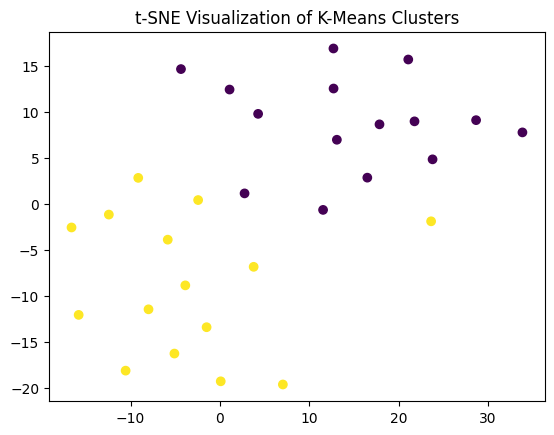

In [183]:
#visualization
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=10, random_state=42)
X_2d = tsne.fit_transform(hybrid_features)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_kmeans, cmap='viridis')
plt.title("t-SNE Visualization of K-Means Clusters")
plt.show()